In [1]:
from google.cloud import bigquery

client = bigquery.Client()
query = """
    SELECT * FROM `numeric-advice-452700-j9.neo_bank_.modelo_prediccion`
"""
df_modelo_prediccion = client.query(query).to_dataframe()

df_modelo_prediccion

/Users/Marco_De_Castilla_V/proyectos/ultima-version/neo-bank/venvPyCaret/lib/python3.10/site-packages/google/cloud/bigquery/table.py:1957: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,user_id,birth_year,country,city,created_date,user_settings_crypto_unlocked,plan,attributes_notifications_marketing_push,attributes_notifications_marketing_email,num_contacts,num_referrals,num_successful_referrals,first_transaction_date,last_transaction_date,num_transactions,num_notifications,dias_a_ultima_txn,dias_inactivo,converted,churned
0,user_10188,1970,GB,Hove,2018-08-09,0,STANDARD,0.0,0.0,4,0,0,2018-08-09 18:04:57.821670+00:00,2019-04-30 21:52:15.954670+00:00,73,11,264,16,True,False
1,user_2270,1976,FR,Nice,2018-03-08,0,STANDARD,0.0,0.0,0,0,0,2018-03-08 21:44:55.595649+00:00,2019-05-07 23:35:16.386649+00:00,66,11,425,9,True,False
2,user_18896,1979,LV,Riga,2018-12-15,0,STANDARD,0.0,0.0,34,0,0,2018-12-15 18:42:56.827315+00:00,2019-05-11 21:25:51.734315+00:00,520,2,147,5,True,False
3,user_12155,1984,PL,Srem,2018-10-01,0,STANDARD,0.0,0.0,93,0,0,2018-10-04 15:17:22.299227+00:00,2019-03-13 16:17:39.389227+00:00,40,10,163,64,True,True
4,user_2988,1987,CH,Basel,2018-03-10,0,STANDARD,0.0,0.0,1,0,0,2018-06-13 12:40:24.276647+00:00,2019-03-14 12:13:25.167647+00:00,38,5,369,63,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19425,user_7733,1970,FR,Les Sables d'Olonne,2018-06-24,1,STANDARD,1.0,1.0,0,0,0,2018-06-24 08:14:10.462808+00:00,2019-05-08 09:45:59.141808+00:00,315,10,318,8,True,False
19426,user_5945,1991,GB,Newcastle Upon Tyne,2018-05-10,1,STANDARD,1.0,1.0,0,0,0,2018-05-19 06:42:57.531492+00:00,2018-12-16 06:27:22.816492+00:00,26,9,220,151,True,True
19427,user_8101,1987,ES,Pozo de Guadalajara,2018-06-22,0,STANDARD,1.0,1.0,0,0,0,2018-06-22 03:55:24.290330+00:00,2019-04-27 13:56:24.458330+00:00,31,7,309,19,True,False
19428,user_19050,1987,FR,Verneuil-sur-Vienne,2018-12-17,0,STANDARD,1.0,1.0,0,0,0,2019-01-08 03:12:55.662612+00:00,2019-04-28 20:54:24.220612+00:00,19,12,132,18,True,False


In [2]:
print(df_modelo_prediccion.shape)
print(df_modelo_prediccion.dtypes)
df_modelo_prediccion.head()
df_modelo_prediccion.isnull().sum()  # Confirma que no hay nulos


(19430, 20)
user_id                                                  object
birth_year                                                Int64
country                                                  object
city                                                     object
created_date                                             dbdate
user_settings_crypto_unlocked                             Int64
plan                                                     object
attributes_notifications_marketing_push                 float64
attributes_notifications_marketing_email                float64
num_contacts                                              Int64
num_referrals                                             Int64
num_successful_referrals                                  Int64
first_transaction_date                      datetime64[us, UTC]
last_transaction_date                       datetime64[us, UTC]
num_transactions                                          Int64
num_notifications           

user_id                                       0
birth_year                                    0
country                                       0
city                                          0
created_date                                  0
user_settings_crypto_unlocked                 0
plan                                          0
attributes_notifications_marketing_push       0
attributes_notifications_marketing_email      0
num_contacts                                  0
num_referrals                                 0
num_successful_referrals                      0
first_transaction_date                      664
last_transaction_date                       664
num_transactions                              0
num_notifications                             0
dias_a_ultima_txn                             0
dias_inactivo                                 0
converted                                     0
churned                                       0
dtype: int64

# LogisticRegression

In [3]:
cols_excluir = [
    'user_id', 
    'first_transaction_date', 
    'last_transaction_date', 
    'created_date',
    'dias_inactivo',
    'dias_a_ultima_txn'
]

features = [col for col in df_modelo_prediccion.columns if col not in cols_excluir + ['churned']]
X = df_modelo_prediccion[features]
y = df_modelo_prediccion['churned']

print(f"Features usadas para el modelo: {features}")


Features usadas para el modelo: ['birth_year', 'country', 'city', 'user_settings_crypto_unlocked', 'plan', 'attributes_notifications_marketing_push', 'attributes_notifications_marketing_email', 'num_contacts', 'num_referrals', 'num_successful_referrals', 'num_transactions', 'num_notifications', 'converted']


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)


(13601, 13) (5829, 13) (13601,) (5829,)


In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Detectar variables categóricas y numéricas
categorical_features = X.select_dtypes(include='object').columns.tolist()
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

# Pipeline con regresión logística como modelo inicial
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced'))
])


In [6]:
model_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['birth_year',
                                                   'user_settings_crypto_unlocked',
                                                   'attributes_notifications_marketing_push',
                                                   'attributes_notifications_marketing_email',
                                                   'num_contacts',
                                                   'num_referrals',
                                                   'num_successful_referrals',
                                                   'num_transactions',
                                                   'num_notifications']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['country', 'city',
                                                   'plan'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [7]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred = model_pipeline.predict(X_test)
y_proba = model_pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))


              precision    recall  f1-score   support

         0.0       0.91      0.72      0.80      3897
         1.0       0.60      0.85      0.70      1932

    accuracy                           0.76      5829
   macro avg       0.75      0.78      0.75      5829
weighted avg       0.80      0.76      0.77      5829

ROC AUC: 0.8619399059955339


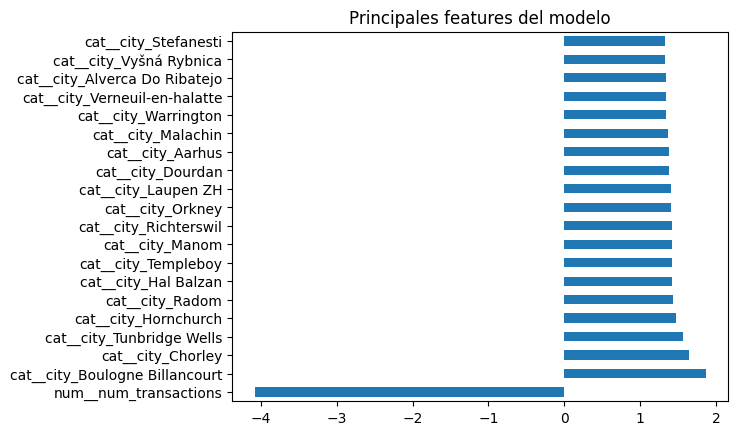

In [8]:
import matplotlib.pyplot as plt
import pandas as pd

coefficients = model_pipeline.named_steps['classifier'].coef_[0]
feature_names = model_pipeline.named_steps['preprocessor'].get_feature_names_out()
feat_importance = pd.Series(coefficients, index=feature_names).sort_values(key=abs, ascending=False)

feat_importance[:20].plot(kind='barh')
plt.title("Principales features del modelo")
plt.show()


# Comparando modelos

In [9]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, roc_auc_score

# Diccionario con los clasificadores que quieres probar
modelos = {
    "RandomForest": RandomForestClassifier(random_state=42),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
    "SVM": SVC(probability=True, random_state=42)
}

for nombre, clasificador in modelos.items():
    print(f"\n=== Modelo: {nombre} ===")
    
    # Crear pipeline completo con el preprocesador y el clasificador
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', clasificador)
    ])
    
    # Entrenar
    pipeline.fit(X_train, y_train)
    
    # Predicciones
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:,1]
    
    # Métricas
    print(classification_report(y_test, y_pred))
    print("ROC AUC:", roc_auc_score(y_test, y_proba))



=== Modelo: RandomForest ===
              precision    recall  f1-score   support

         0.0       0.84      0.91      0.87      3897
         1.0       0.78      0.65      0.71      1932

    accuracy                           0.82      5829
   macro avg       0.81      0.78      0.79      5829
weighted avg       0.82      0.82      0.82      5829

ROC AUC: 0.8782113809475994

=== Modelo: GradientBoosting ===
              precision    recall  f1-score   support

         0.0       0.85      0.91      0.88      3897
         1.0       0.79      0.67      0.72      1932

    accuracy                           0.83      5829
   macro avg       0.82      0.79      0.80      5829
weighted avg       0.83      0.83      0.83      5829

ROC AUC: 0.8949832540931044

=== Modelo: SVM ===
              precision    recall  f1-score   support

         0.0       0.87      0.84      0.86      3897
         1.0       0.70      0.74      0.72      1932

    accuracy                           0.

# PayCaret

In [22]:
from pycaret.classification import *

clf_setup = setup(
    data=df_limpio,
    target='churned',
    train_size=0.7,
    session_id=42
)




,Description,Value
0,Session id,42
1,Target,churned
2,Target type,Binary
3,Original data shape,"(19430, 18)"
4,Transformed data shape,"(19430, 23)"
5,Transformed train set shape,"(13601, 23)"
6,Transformed test set shape,"(5829, 23)"
7,Numeric features,11
8,Categorical features,4
9,Preprocess,True


In [23]:
best_model = compare_models()


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
dummy,Dummy Classifier,0.6685,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0350


In [24]:
df_modelo_prediccion['churned'].value_counts(normalize=True)


churned
False    0.668502
True     0.331498
Name: proportion, dtype: Float64

In [25]:
get_config('X_train').info()


<class 'pandas.core.frame.DataFrame'>
Index: 13601 entries, 17724 to 16666
Data columns (total 17 columns):
 #   Column                                    Non-Null Count  Dtype   
---  ------                                    --------------  -----   
 0   user_id                                   13601 non-null  category
 1   birth_year                                13601 non-null  Int64   
 2   country                                   13601 non-null  category
 3   city                                      13601 non-null  category
 4   created_date                              13601 non-null  dbdate  
 5   user_settings_crypto_unlocked             13601 non-null  Int64   
 6   plan                                      13601 non-null  category
 7   attributes_notifications_marketing_push   13601 non-null  float32 
 8   attributes_notifications_marketing_email  13601 non-null  float32 
 9   num_contacts                              13601 non-null  Int64   
 10  num_referrals          

In [26]:
df_modelo_prediccion.isnull().sum()


user_id                                       0
birth_year                                    0
country                                       0
city                                          0
created_date                                  0
user_settings_crypto_unlocked                 0
plan                                          0
attributes_notifications_marketing_push       0
attributes_notifications_marketing_email      0
num_contacts                                  0
num_referrals                                 0
num_successful_referrals                      0
first_transaction_date                      664
last_transaction_date                       664
num_transactions                              0
num_notifications                             0
dias_a_ultima_txn                             0
dias_inactivo                                 0
converted                                     0
churned                                       0
dtype: int64

# GradientBoosting

In [27]:
from sklearn.ensemble import GradientBoostingClassifier

# Vuelve a crear el pipeline con el mejor modelo
best_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(random_state=42))
])

# Entrena con los datos de entrenamiento
best_model.fit(X_train, y_train)

# Evalúa en el set de prueba
from sklearn.metrics import classification_report, roc_auc_score

y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))


              precision    recall  f1-score   support

         0.0       0.85      0.91      0.88      3897
         1.0       0.79      0.67      0.72      1932

    accuracy                           0.83      5829
   macro avg       0.82      0.79      0.80      5829
weighted avg       0.83      0.83      0.83      5829

ROC AUC: 0.8949832540931044


In [29]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__learning_rate': [0.01, 0.1, 0.2],
    'classifier__max_depth': [3, 5, 7]
}

grid_search = GridSearchCV(
    best_model,
    param_grid,
    cv=3,
    scoring='roc_auc',
    verbose=2,
    n_jobs=1  # Usa 1 núcleo para evitar problemas de paralelización
)


grid_search.fit(X_train, y_train)

print("Mejores parámetros encontrados:", grid_search.best_params_)
print("Mejor ROC AUC en validación cruzada:", grid_search.best_score_)


Fitting 3 folds for each of 18 candidates, totalling 54 fits
[CV] END classifier__learning_rate=0.01, classifier__max_depth=3, classifier__n_estimators=100; total time=   3.8s
[CV] END classifier__learning_rate=0.01, classifier__max_depth=3, classifier__n_estimators=100; total time=   3.7s
[CV] END classifier__learning_rate=0.01, classifier__max_depth=3, classifier__n_estimators=100; total time=   3.9s
[CV] END classifier__learning_rate=0.01, classifier__max_depth=3, classifier__n_estimators=200; total time=   7.4s
[CV] END classifier__learning_rate=0.01, classifier__max_depth=3, classifier__n_estimators=200; total time=   7.4s
[CV] END classifier__learning_rate=0.01, classifier__max_depth=3, classifier__n_estimators=200; total time=   7.5s
[CV] END classifier__learning_rate=0.01, classifier__max_depth=5, classifier__n_estimators=100; total time=   4.5s
[CV] END classifier__learning_rate=0.01, classifier__max_depth=5, classifier__n_estimators=100; total time=   4.4s
[CV] END classifier

In [30]:
# Actualizar el clasificador con los mejores parámetros
from sklearn.ensemble import GradientBoostingClassifier

mejor_clasificador = GradientBoostingClassifier(
    learning_rate=0.1,
    max_depth=5,
    n_estimators=100,
    random_state=42
)

# Crear pipeline final
from sklearn.pipeline import Pipeline

modelo_final = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', mejor_clasificador)
])

# Entrenar con TODOS los datos (X_train + X_test)
modelo_final.fit(X, y)


Pipeline(memory=None,
         steps=[('preprocessor',
                 ColumnTransformer(n_jobs=None, remainder='drop',
                                   sparse_threshold=0.3,
                                   transformer_weights=None,
                                   transformers=[('num',
                                                  StandardScaler(copy=True,
                                                                 with_mean=True,
                                                                 with_std=True),
                                                  ['birth_year',
                                                   'user_settings_crypto_unlocked',
                                                   'attributes_notifications_marketing_push',
                                                   'attributes_notifications_marketing_email',
                                                   'num_c...
                                            criterion='friedman_mse', init=None,
                                            learning_rate=0.1, loss='log_loss',
                                            max_depth=5, max_features=None,
                                            max_leaf_nodes=None,
                                            min_impurity_decrease=0.0,
                                            min_samples_leaf=1,
                                            min_samples_split=2,
                                            min_weight_fraction_leaf=0.0,
                                            n_estimators=100,
                                            n_iter_no_change=None,
                                            random_state=42, subsample=1.0,
                                            tol=0.0001, validation_fraction=0.1,
                                            verbose=0, warm_start=False))],
         verbose=False)

In [31]:
import joblib

joblib.dump(modelo_final, 'modelo_churn.pkl')


['modelo_churn.pkl']